<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/02-supervised-learning/01-classification/Predicting-Customer-Churn/Deep_Dive_into_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Project Title: "Deep Dive into Customer Churn 🔍📉"


## 🌐 Overview
In this project, we perform an advanced and insightful Exploratory Data Analysis (EDA) on the Telco Customer Churn dataset, aiming to uncover the underlying patterns behind customer attrition in the telecom sector.

We investigate a wide range of features — from demographic data 👤, contract types 📄, and service usage 📡, to financial behavior 💳 — in relation to customer churn 🔁.

Using interactive and visually rich plots such as sunburst charts 🌞, treemaps 🌲, violin plots 🎻, and correlation heatmaps 🔥, we go beyond basic stats to explore multi-dimensional relationships and generate actionable insights.

The ultimate goal is to understand what drives customers to leave, and lay a strong analytical foundation for churn prediction models 🎯

## Importing necessary libraries

In [2]:
!pip install optuna -q
!pip install imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 11.3 MB/s eta 0:00:00


In [45]:
import pickle
import joblib
import optuna
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import altair as alt
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
from optuna.storages import RDBStorage
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, \
 f1_score, confusion_matrix, classification_report, matthews_corrcoef, \
 roc_auc_score, roc_curve, ConfusionMatrixDisplay, fbeta_score, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("All libraries has been imported!")

All libraries has been imported!


## Loading the dataset

In [4]:
# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


## Exploratory Data Analysis

In [ ]:
print(f'Number of rows in dataset: {df.shape[0]}')
print(f'Number of columns in dataset: {df.shape[1]}')

Number of rows in dataset: 7043
Number of columns in dataset: 21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762
std,0.369,24.559,30.090
min,0.000,0.000,18.250
25%,0.000,9.000,35.500
50%,0.000,29.000,70.350
75%,0.000,55.000,89.850
max,1.000,72.000,118.750


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print(f'Total number of missing values: {df.isnull().sum().sum()}')

Total number of missing values: 0


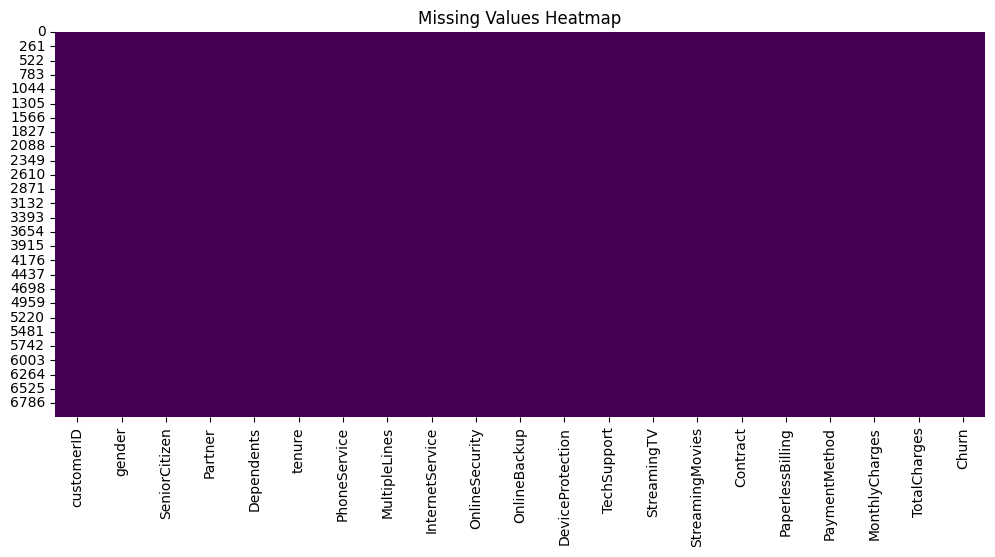

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


In [ ]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print('Numerical Columns:')
print(f'Number of numerical is: {len(num_cols)}')
print(num_cols)
print('\nCategorical Columns:')
print(f'Number of categorical is: {len(cat_cols)}')
print(cat_cols)

Numerical Columns:
Number of numerical is: 3
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

Categorical Columns:
Number of categorical is: 18
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


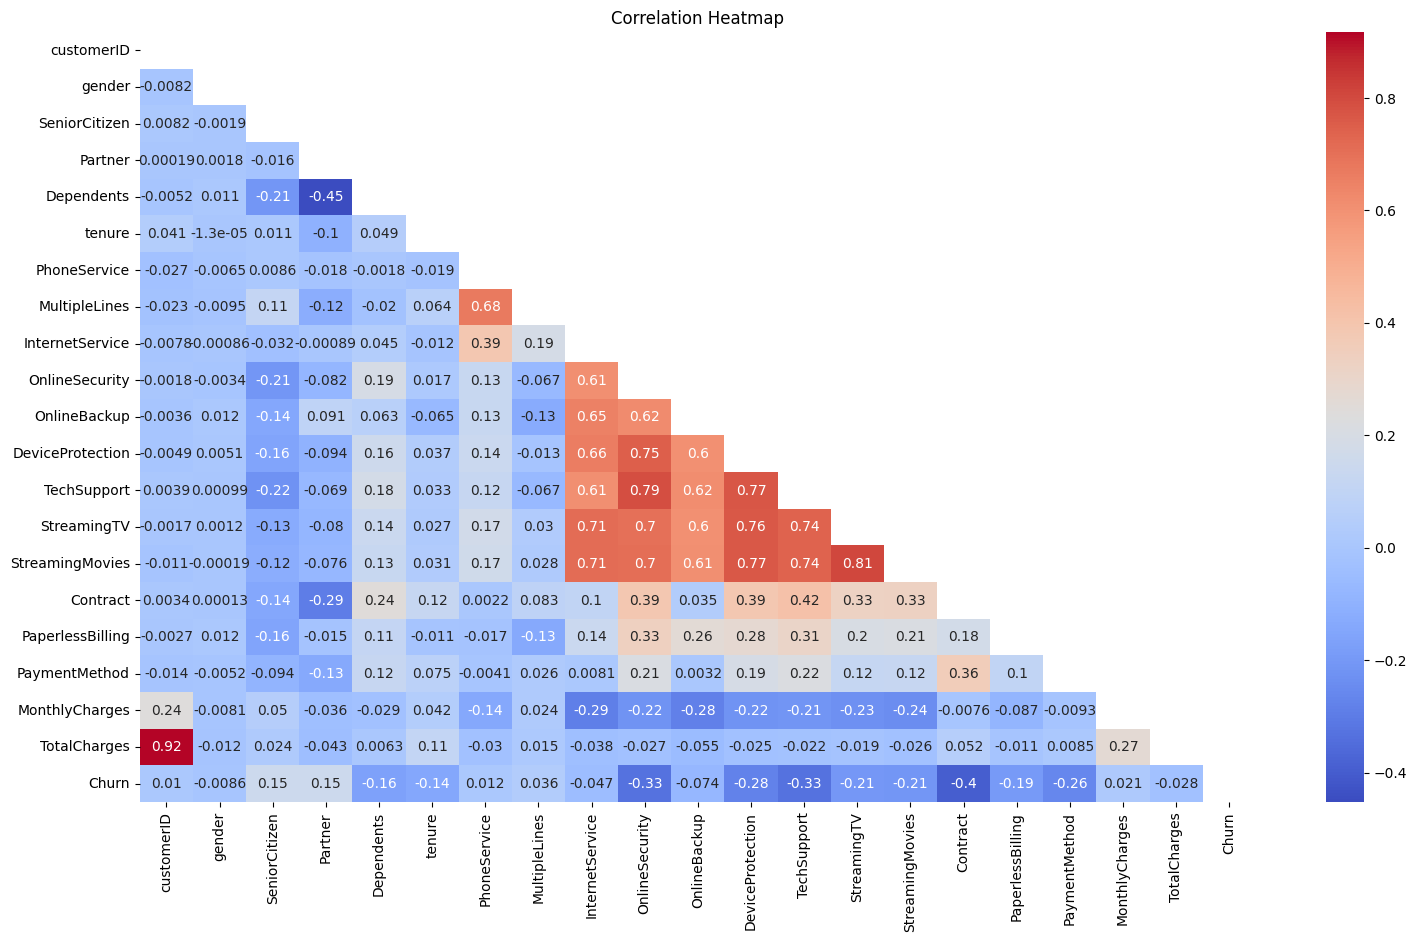

In [ ]:
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

plt.figure(figsize=(18, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
def check_target_distribution(df, target_col):
  plt.figure(figsize=(6, 4))
  ax = sns.countplot(df, x=target_col, palette='Blues')

  for p in ax.patches:
      ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 9), textcoords='offset points')

  plt.ylim(0, 6000)
  plt.title("Distribution of Target columns")
  plt.show()

  print()
  print(df['Churn'].value_counts(normalize=True) * 100)

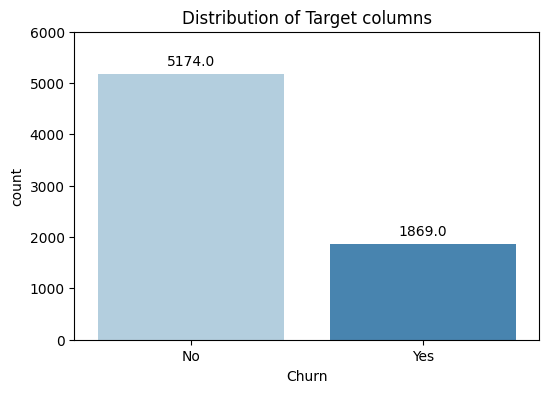


Churn
No    73.463
Yes   26.537
Name: proportion, dtype: float64


In [ ]:
check_target_distribution(df, 'Churn')

In [47]:
num_cols = df.select_dtypes(include='number').columns

fig = make_subplots(rows=1, cols=len(num_cols), subplot_titles=num_cols, horizontal_spacing=0.05)

colors = px.colors.qualitative.Plotly

for i, col in enumerate(num_cols):
    fig.add_trace(
        go.Box(
            y=df[col],
            name=col,
            marker_color=colors[i % len(colors)],
            boxpoints='outliers',
            jitter=0.3,
            pointpos=-1.8,
            line=dict(width=1),
            fillcolor='rgba(255,255,255,0)'
        ),
        row=1,
        col=i + 1
    )

fig.update_layout(
    height=500,
    width=350 * len(num_cols),
    title_text="🔍 Interactive Outlier Detection for Numerical Features",
    showlegend=False,
    template="plotly_white"
)

fig.show()

In [ ]:
fig = go.Figure(data=[go.Pie(
    labels=['No', 'Yes'],
    values=df['Churn'].value_counts(),
    hole=0.4,
    textinfo='label+percent+value',
    marker=dict(colors=['#00BFA6', '#6A5ACD'])
)])
fig.update_layout(title_text='Customer Churn Distribution')
fig.show()

In [ ]:
for col in cat_cols:
  print(f'--- {col} ---')
  print(f'Number of unique values is: {df[col].nunique()}')
  print(df[col].value_counts())
  print()

--- customerID ---
Number of unique values is: 7043
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

--- gender ---
Number of unique values is: 2
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Number of unique values is: 2
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Number of unique values is: 2
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
Number of unique values is: 2
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
Number of unique values is: 3
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
Number of unique values is: 3
InternetService
Fiber optic    3096
DSL            2421
No

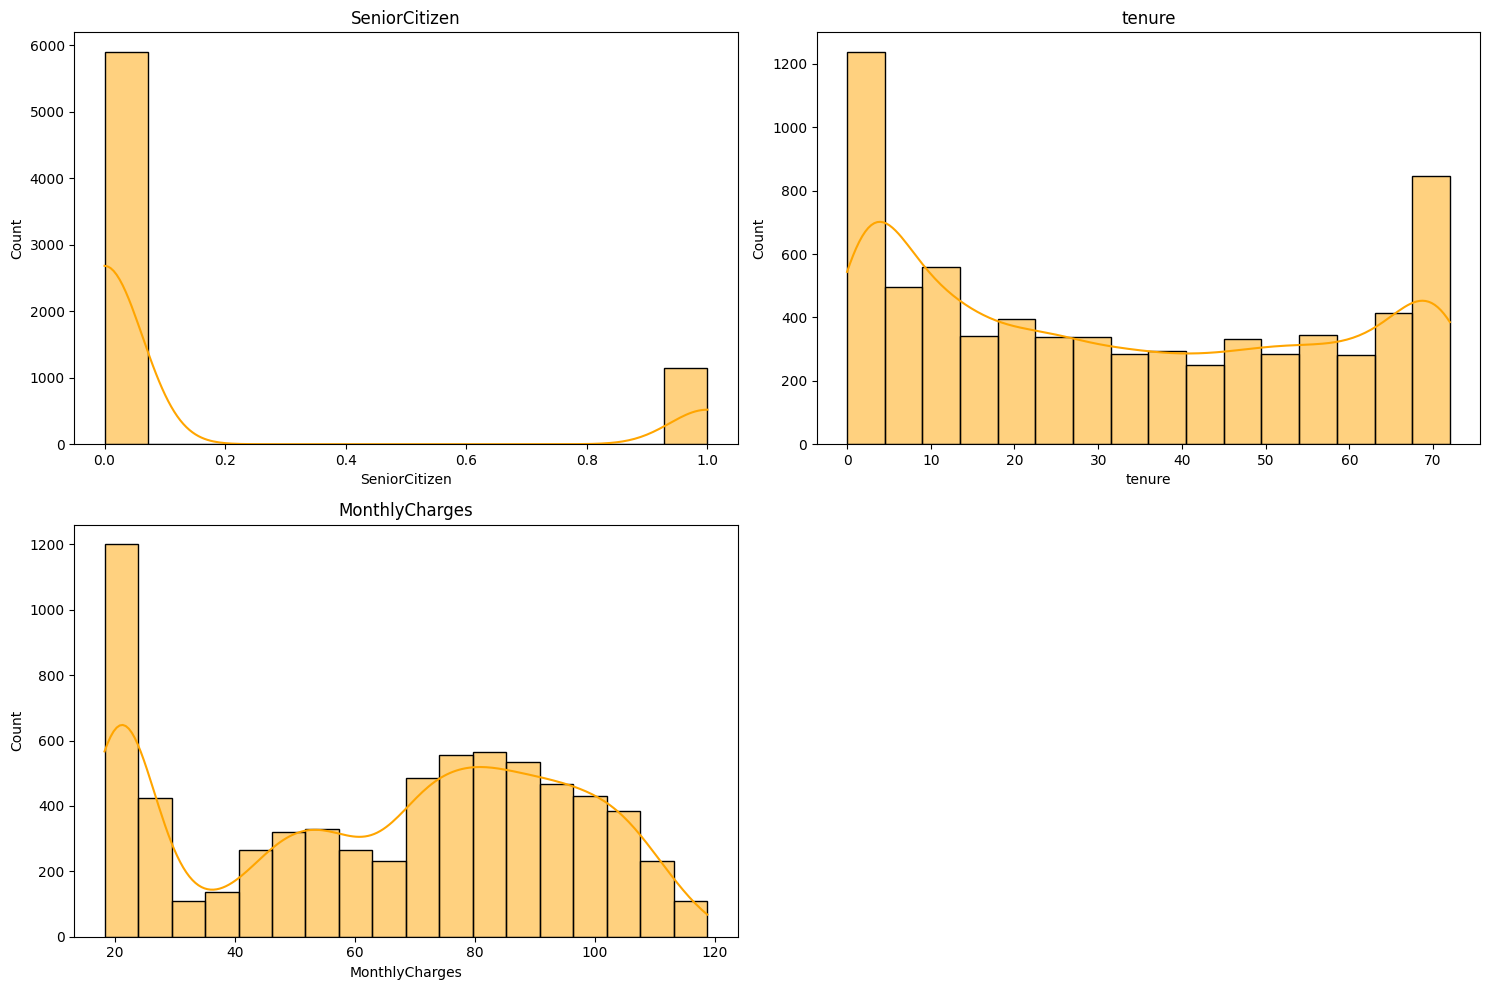

In [ ]:
# plot histogram of all cols
plt.figure(figsize=(15, 10))
for i, col in enumerate(df[num_cols].columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='orange')
    plt.title(col)
plt.tight_layout()
plt.show()

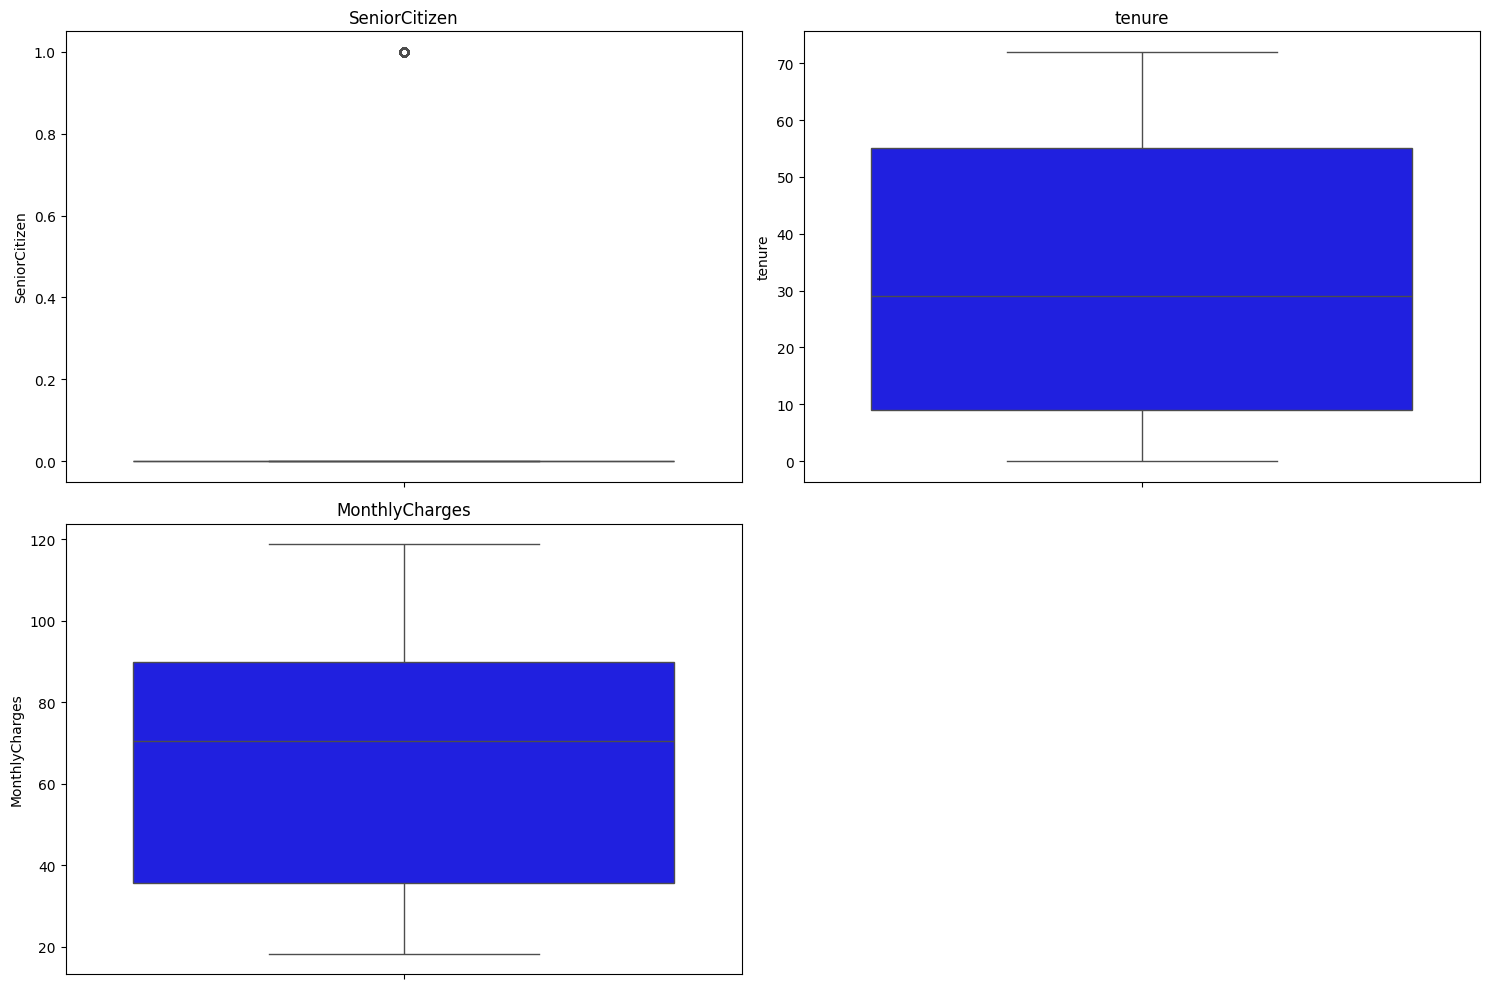

In [ ]:
# Plot boxplot of num cols
plt.figure(figsize=(15, 10))
for i, col in enumerate(df[num_cols].columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(df[col], color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

### Which contract type has the highest churn rate?


In [ ]:
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290,42.710
One year,88.730,11.270
Two year,97.168,2.832


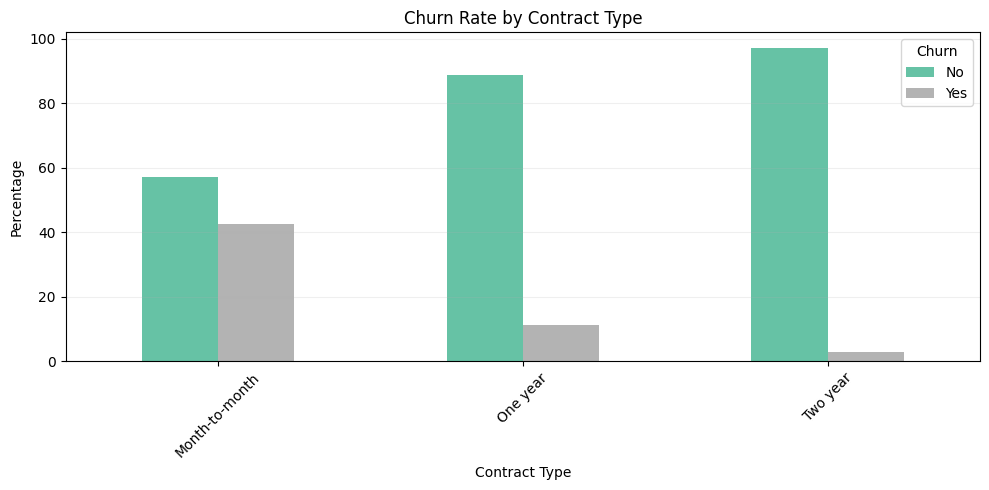

In [ ]:
churn_by_contract.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.xlabel('Contract Type')
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.treemap(df,
                 path=['Contract', 'Churn'],
                 values=None,
                 color='Churn',
                 title='Churn by Contract Type (Treemap)',
                 color_discrete_map={'Yes': 'crimson', 'No': 'lightgreen'})

fig.show()

### 🧠 Interpretation:
📈 Customers with Month-to-month contracts have the highest churn rate.

🟡 Those with One year contracts churn less.

🟢 Two year contracts are associated with the lowest churn.

This suggests that contract duration significantly impacts customer retention.

---

### 💡 Business Insight:
Encourage customers to switch to longer-term contracts to reduce churn.

Offering discounts or incentives for yearly or 2-year plans could increase retention.

---

### 🧠 ML Modeling Note:
Contract is a highly informative categorical feature and should be properly encoded (e.g., One-Hot Encoding) before feeding into the model.

### How does the customer's tenure relate to churn?


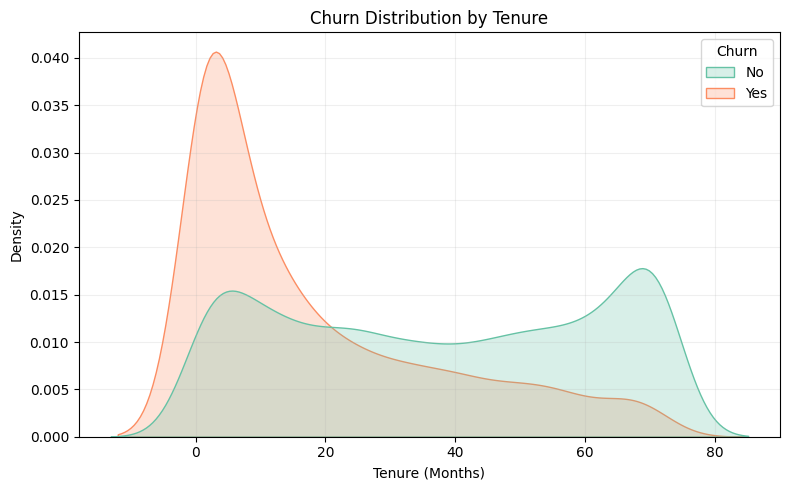

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='Set2')
plt.title('Churn Distribution by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.histogram(df, x='tenure', color='Churn', nbins=30, barmode='overlay',
                   marginal='rug', title='Customer Tenure Distribution by Churn',
                   color_discrete_map={'Yes': 'crimson', 'No': 'lightgreen'})

fig.show()

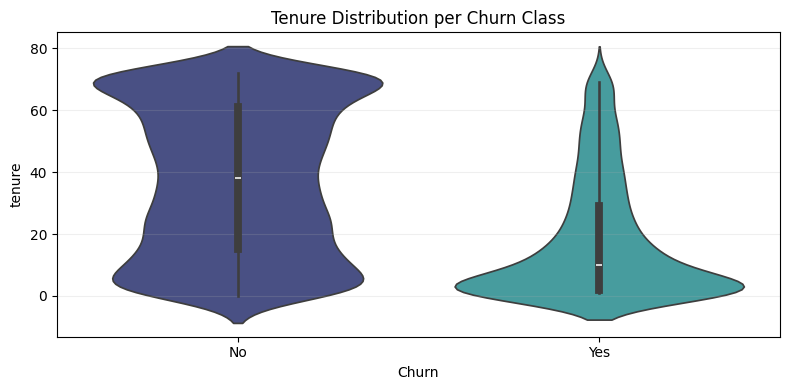

In [ ]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='Churn', y='tenure', palette='mako')
plt.title('Tenure Distribution per Churn Class')
plt.grid(axis='y', alpha=.2)
plt.tight_layout()
plt.show()

### 🧠 Interpretation:
📉 Churn is significantly higher for customers with low tenure.

🔁 Long-term customers (tenure > 30 months) tend to stay and churn less.

💥 The highest churn spike is observed within the first 6 months, indicating a weak onboarding or engagement strategy.

---

### 💡 Business Insight:
🚨 First few months are critical — focus on onboarding, support, and customer satisfaction early.

Consider offering loyalty bonuses for reaching 6-month and 1-year milestones.

Track behavior closely for customers within their first 3 months — they are your red zone.

---

### 🧠 ML Modeling Note:
tenure is a highly informative numeric feature.

Can optionally be binned into categories (e.g., 0–6, 6–12, 12–24, 24+ months) if model benefits from categorical treatment.

Feature scaling (e.g., StandardScaler) might help if you're using algorithms sensitive to scale (like KNN or Logistic Regression).

### Do customers with higher monthly charges churn more frequently?


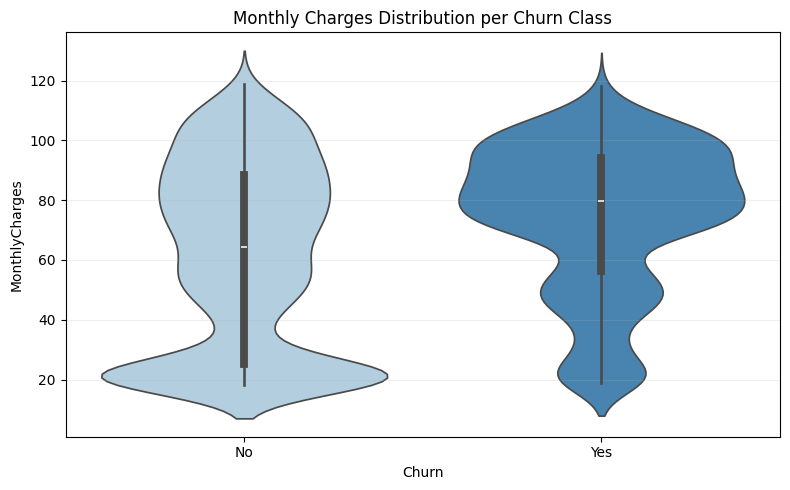

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Churn', y='MonthlyCharges', palette='Blues')
plt.title('Monthly Charges Distribution per Churn Class')
plt.grid(axis='y', alpha=.2)
plt.tight_layout()
plt.show()

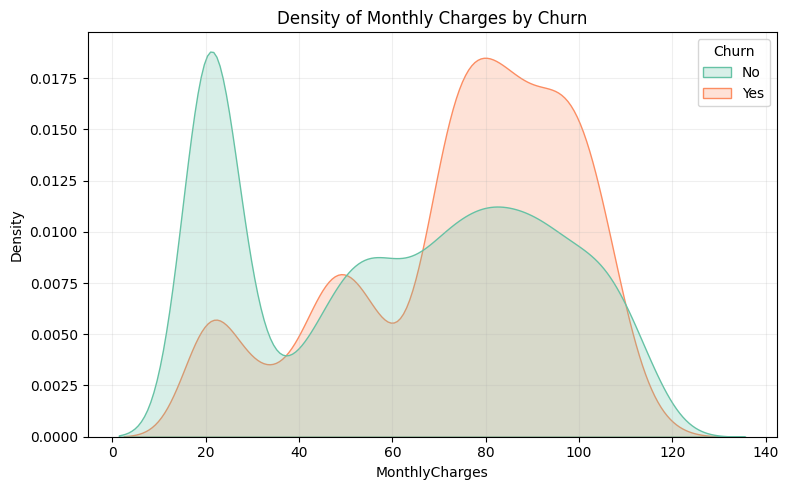

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='Set2')
plt.title("Density of Monthly Charges by Churn")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.box(df, x='Churn', y='MonthlyCharges', color='Churn',
             title='Monthly Charges by Churn (Box Plot)',
             color_discrete_map={'Yes': 'crimson', 'No': 'green'})

fig.show()

### 🔍 Interpretation
Customers who churn (Churn = Yes) tend to have higher monthly charges on average.

The density peak of churners is found between $70–$100.

In contrast, non-churned customers are spread across the full price range, often with lower charges.

---

### 💡 Business Insight
High-paying customers might feel they are not getting enough value for what they pay.

These customers are at higher risk of churn.

Solutions include tiered discounts, premium support, or value bundling for high-tier users.

---

### 🧠 ML Modeling Note
MonthlyCharges is a strong numerical feature.

Consider testing interaction terms (e.g., MonthlyCharges × Contract) or applying log transformation.

No need to bin this feature unless interpretability is a major concern.



### What combination of gender, senior citizen status, and partner status results in the highest churn rate?


In [ ]:
fig = px.sunburst(df, path=['gender', 'SeniorCitizen', 'Partner', 'Churn'],
                  title='Churn rate Across Demographic Segments',
                  color='Churn',
                  color_discrete_map={'Yes': 'crimson', 'No': 'lightgreen'})

fig.show()

In [ ]:
fig = px.treemap(df, path=['gender', 'SeniorCitizen', 'Partner', 'Churn'],
                 title='Churn by Senior x Partner x Churn',
                 color='Churn')
fig.show()

### 🔍 Interpretation
1️⃣ Senior citizens have a higher churn rate than non-seniors, especially those without partners.

2️⃣ Among males, senior non-partners show the highest churn risk.

3️⃣ Females with partners and not seniors tend to churn less frequently.

---

### 💡 Business Insight
🧓 Seniors, especially those without a partner, may need extra support or simpler service packages.

💬 Personalization campaigns targeting single senior males could improve retention.

👭 Customers with partners may feel more stable or supported, and thus less likely to churn.

---

### 🧠 ML Modeling Note
- Combine gender, SeniorCitizen, and Partner into interaction terms or one-hot features for tree-based models.

- You can also combine them into a new column like demo_group = 'Male-Senior-NoPartner' for interpretable insights.

- These combinations can drive segmentation in clustering or decision tree splits.



### Which type of internet service has the highest churn rate?


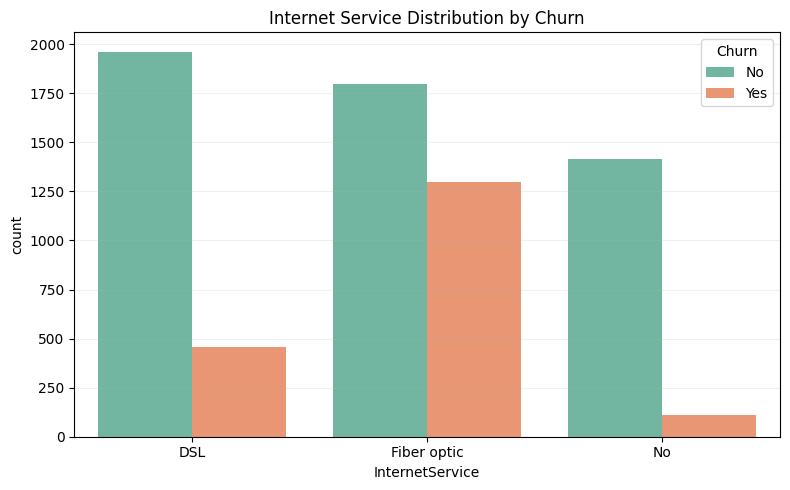

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(df, x='InternetService', hue='Churn', palette='Set2')
plt.title("Internet Service Distribution by Churn")
plt.grid(axis='y', alpha=.2)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.histogram(df, x='InternetService', color='Churn', barmode='group',
                   title='Churn by InternetService Type (Grouped)',
                   color_discrete_map={'Yes': 'crimson', 'No': 'lightgreen'})
fig.show()

In [ ]:
df_pct = round((df.groupby(['InternetService', 'Churn']).size() / df.groupby(['InternetService']).size() * 100), 2).reset_index(name='Percent')

alt.Chart(df_pct).mark_bar().encode(
    x=alt.X('InternetService:N', title='Internet Service'),
    y=alt.Y('Percent:Q', title='Churn Rate (%)'),
    color=alt.Color('Churn:N', title='Churn', scale=alt.Scale(domain=['Yes', 'No'], range=['crimson', 'lightgreen'])),
    tooltip=['InternetService', 'Churn', 'Percent']
).properties(
    title='Churn Rate by Internet Service',
    width=600,
    height=400
).interactive()

alt.Chart(...)

### 🔍 Interpretation
1️⃣ Fiber optic users have the highest churn rate among all groups.

2️⃣ Customers with no internet service churn the least — possibly because they use minimal services and are more stable.

3️⃣ DSL users are somewhere in between, showing moderate churn.

---

### 💡 Business Insight
Fiber optic customers may have higher expectations, so poor service or pricing could quickly trigger churn.

Consider offering loyalty incentives for fiber optic users or bundling internet with premium support.

Customers with no internet are often stable low-value clients — upsell opportunity!

---

### 🧠 ML Modeling Note
InternetService is a strong categorical predictor.

Encode with One-Hot for most ML models.

You could also combine this with other service columns (like StreamingTV, TechSupport) for compound service profiles.

### How do additional services like OnlineSecurity, TechSupport, and StreamingTV impact customer churn?



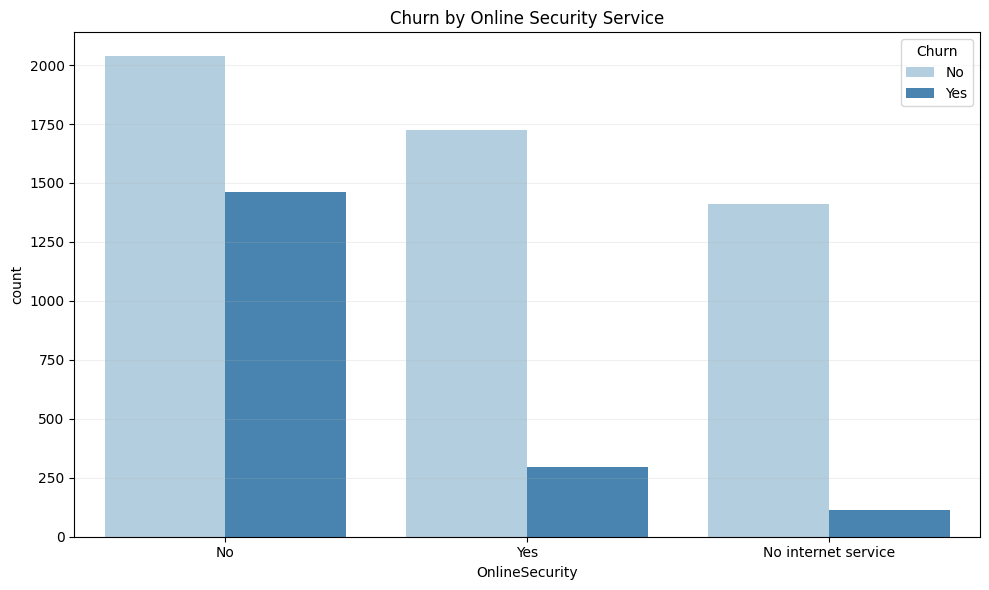

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(df, x='OnlineSecurity', hue='Churn', palette='Blues')
plt.title('Churn by Online Security Service')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.histogram(df, x='OnlineSecurity', color='Churn', barmode='group',
                   title='Churn by OnlineSecurity Service',
                   color_discrete_map={'Yes': 'crimson', 'No': 'lightgreen'})

fig.show()

In [ ]:
# Melt features into long-form for altair
melted_df = df.melt(id_vars='Churn', value_vars=['OnlineSecurity', 'TechSupport', 'StreamingTV'],
                    var_name='Service', value_name='Subscription')

service_churn = melted_df.groupby(['Service', 'Subscription', 'Churn']).size().reset_index(name='count')

alt.Chart(service_churn).mark_bar().encode(
    x='Subscription:N',
    y='count:Q',
    color='Churn:N',
    column='Service:N',
    tooltip=['Service', 'Subscription', 'Churn', 'count']
).properties(
    title='Churn Breakdown by Multiple Services',
    width=400,
    height=300
)

alt.Chart(...)

### 🔍 Interpretation
1️⃣ Customers without OnlineSecurity or TechSupport churn at a significantly higher rate.

2️⃣ StreamingTV has a mild correlation with churn, but not as strong.

3️⃣ Customers with "No Internet Service" generally churn less, as they are often low-involvement users.

---

💡 Business Insight
Security and support services seem to boost customer retention.

Offer discounted bundles that include these add-ons to increase stickiness.

Encourage adoption of value-added services during onboarding to reduce early churn.

---

🧠 ML Modeling Note
- Encode these categorical features using One-Hot or Ordinal if "No internet service" is frequent.

- Consider creating binary flags like HasSecurity, HasSupport, HasStreaming.

- These features are valuable interaction points when combined with tenure or contract.



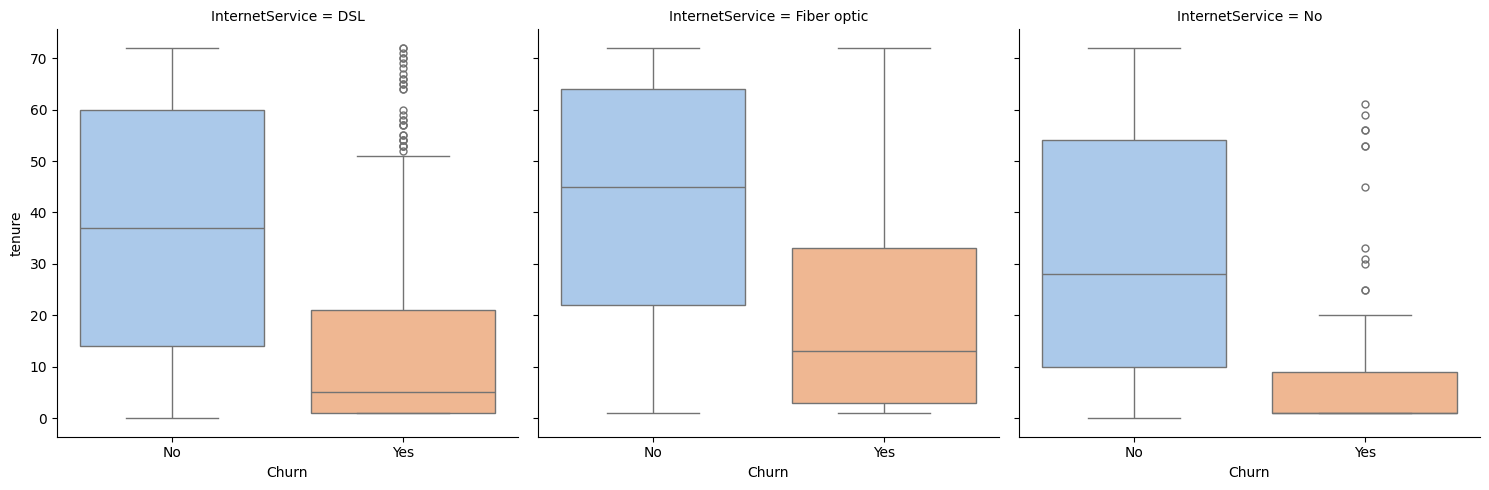

In [ ]:
# How tenure impacts churn across different internet services
sns.catplot(data=df, x='Churn', y='tenure', col='InternetService', kind='box', hue='Churn', palette='pastel')
plt.show()

## Data Preprocessing

In [6]:
df.drop('customerID', axis=1, inplace=True)

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(r'\s+', np.nan, regex=True).astype(float)

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


In [11]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [12]:
class FeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['HasInternet'] = X['InternetService'].fillna('No').apply(lambda x: 1 if x != 'No' else 0)

        X['HasStreaming'] = (
            (X['StreamingTV'].fillna('No') != 'No') |
            (X['StreamingMovies'].fillna('No') != 'No')
        ).astype(int)

        sec_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
        X['HasSecurityServices'] = X[sec_services].fillna('No').apply(lambda row: sum(v != 'No' for v in row), axis=1)

        def tenure_group(t):
            if pd.isna(t): return 'Unknown'
            if t <= 12: return '0-1yr'
            elif t <= 24: return '1-2yr'
            elif t <= 60: return '2-5yr'
            else: return '5yr+'

        X['tenure_group'] = X['tenure'].apply(tenure_group)

        X['AvgMonthlyCost'] = X.apply(lambda row:
            row['TotalCharges'] / row['tenure'] if pd.notna(row['TotalCharges']) and pd.notna(row['tenure']) and row['tenure'] > 0
            else 0, axis=1)

        X['LongTermContract'] = X['Contract'].fillna('Month-to-month').apply(lambda x: 1 if x in ['One year', 'Two year'] else 0)

        service_cols = [
            'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies'
        ]
        X['TotalServices'] = X[service_cols].fillna('No').apply(lambda row: sum(v != 'No' for v in row), axis=1)

        X['AutoPay'] = X['PaymentMethod'].fillna('').str.lower().str.contains('automatic').astype(int)

        return X

In [13]:
feature_adder = FeatureAdder()
X_train_fe = feature_adder.fit_transform(X_train)

num_cols = X_train_fe.select_dtypes(include='number').columns.tolist()
cat_cols = X_train_fe.select_dtypes(include='object').columns.tolist()

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=7)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

pipeline = ImbPipeline(steps=[
    ('feature_engineering', FeatureAdder()),
    ('preprocessor', preprocessor),
    ('adasyn', ADASYN(random_state=42)),
    ('model', XGBClassifier(random_state=42))
])

pipeline.fit(X_train, y_train_encoded)


fe_only = Pipeline(steps=[
    ('feature_engineering', FeatureAdder()),
    ('preprocessor', preprocessor)
])

fe_only.fit(X_train, y_train_encoded)

X_train_preprocessed = fe_only.transform(X_train)
X_test_preprocessed = fe_only.transform(X_test)

X_train_preprocessed = pd.DataFrame(X_train_preprocessed, columns=fe_only.named_steps['preprocessor'].get_feature_names_out())
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=fe_only.named_steps['preprocessor'].get_feature_names_out())


In [14]:
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train_preprocessed, y_train_encoded)

In [15]:
fig = go.Figure(data=[go.Pie(
    labels=['No', 'Yes'],
    values=pd.DataFrame(y_resampled).value_counts(),
    hole=0.4,
    textinfo='label+percent+value',
    marker=dict(colors=['#00BFA6', '#6A5ACD'])
)])
fig.update_layout(title_text='Customer Churn Distribution (After resampling)')
fig.show()

In [16]:
X_train_preprocessed.shape

(5634, 40)

In [17]:
X_test_preprocessed.shape

(1409, 40)

## Modeling and Evaluating

In [18]:
def evaluate_model_full(model, X_train, y_train, X_test, y_test, model_name, result_df, beta=2, k=5):
    # Convert y_train and y_test to NumPy arrays for consistent indexing
    y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train
    y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test

    # ---------- Cross-Validation ----------
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    metrics_cv = {k: [] for k in ['acc', 'prec', 'rec', 'f1', 'fbeta', 'mcc', 'roc_auc']}
    all_y_true_cv = []
    all_y_probs_cv = []

    # Convert to DataFrame for cross-validation
    X_train_df = pd.DataFrame(X_train, columns=X_train.columns) # Use X_train directly

    for train_idx, val_idx in skf.split(X_train_df, y_train_np): # Use y_train_np here
        X_tr, X_val = X_train_df.iloc[train_idx], X_train_df.iloc[val_idx]
        y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx] # Use y_train_np here

        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        try:
            y_prob_val = model.predict_proba(X_val)[:, 1]
        except:
            y_prob_val = model.decision_function(X_val)
            y_prob_val = (y_prob_val - y_prob_val.min()) / (y_prob_val.max() - y_prob_val.min())


        metrics_cv['acc'].append(balanced_accuracy_score(y_val, y_pred_val))
        metrics_cv['prec'].append(precision_score(y_val, y_pred_val))
        metrics_cv['rec'].append(recall_score(y_val, y_pred_val))
        metrics_cv['f1'].append(f1_score(y_val, y_pred_val))
        metrics_cv['fbeta'].append(fbeta_score(y_val, y_pred_val, beta=beta))
        metrics_cv['mcc'].append(matthews_corrcoef(y_val, y_pred_val))
        metrics_cv['roc_auc'].append(roc_auc_score(y_val, y_prob_val))

        all_y_true_cv.extend(y_val)
        all_y_probs_cv.extend(y_prob_val)

    # ---------- Evaluation on Test Set ----------
    # Use DataFrame for testing
    model.fit(X_train, y_train_np) # Fit on the full training DataFrame, use y_train_np
    y_pred_test = model.predict(X_test)
    try:
        y_prob_test = model.predict_proba(X_test)[:, 1]
    except:
        y_prob_test = model.decision_function(X_test)
        y_prob_test = (y_prob_test - y_prob_test.min()) / (y_prob_test.max() - y_prob_test.min())


    acc_test = balanced_accuracy_score(y_test_np, y_pred_test) # Use y_test_np here
    prec_test = precision_score(y_test_np, y_pred_test) # Use y_test_np here
    rec_test = recall_score(y_test_np, y_pred_test) # Use y_test_np here
    f1_test = f1_score(y_test_np, y_pred_test) # Use y_test_np here
    fbeta_test = fbeta_score(y_test_np, y_pred_test, beta=beta) # Use y_test_np here
    mcc_test = matthews_corrcoef(y_test_np, y_pred_test) # Use y_test_np here
    roc_auc_test = roc_auc_score(y_test_np, y_prob_test) # Use y_test_np here

    # ---------- Plot ROC & PR on Test Set ----------
    fpr, tpr, _ = roc_curve(y_test_np, y_prob_test) # Use y_test_np here
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_np, y_prob_test) # Use y_test_np here

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_test:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(recall_curve, precision_curve)
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.tight_layout()
    plt.show()

    # ---------- Add to Results ----------
    new_row = pd.DataFrame([{
        'Model': model_name,
        # Train (CV)
        'Train Accuracy': np.mean(metrics_cv['acc']),
        'Train Precision': np.mean(metrics_cv['prec']),
        'Train Recall': np.mean(metrics_cv['rec']),
        'Train F1': np.mean(metrics_cv['f1']),
        'Train Fβ': np.mean(metrics_cv['fbeta']),
        'Train MCC': np.mean(metrics_cv['mcc']),
        'Train ROC AUC': np.mean(metrics_cv['roc_auc']),
        # Test
        'Test Accuracy': acc_test,
        'Test Precision': prec_test,
        'Test Recall': rec_test,
        'Test F1': f1_test,
        'Test Fβ': fbeta_test,
        'Test MCC': mcc_test,
        'Test ROC AUC': roc_auc_test,
    }])

    result_df = pd.concat([result_df, new_row], ignore_index=True)
    return result_df

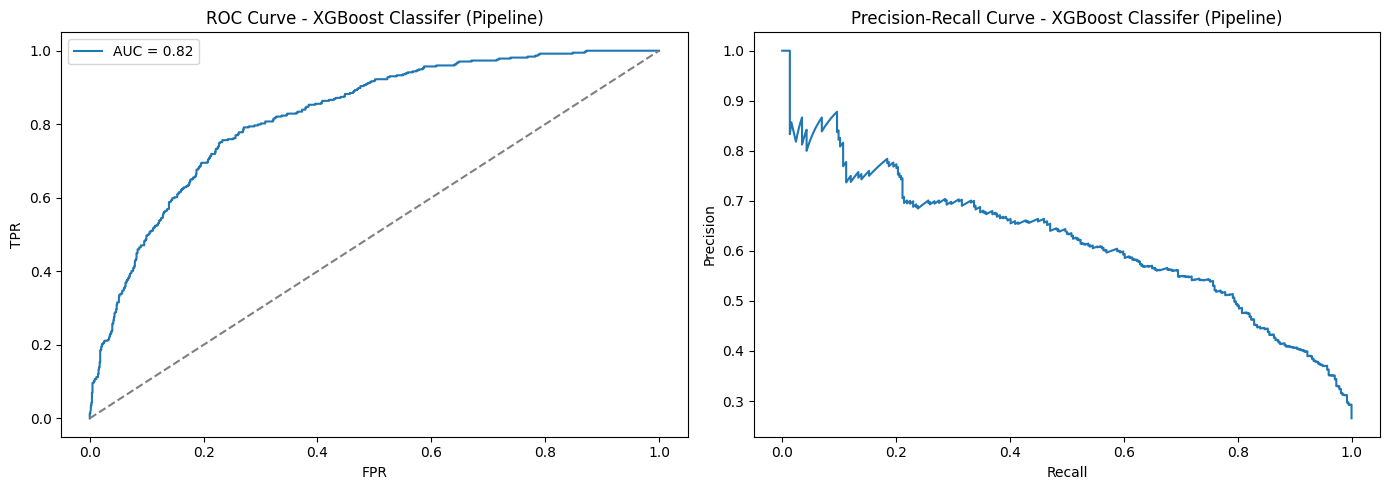

In [19]:
pipeline_result = pd.DataFrame()

pipeline_result = evaluate_model_full(
    pipeline,
    X_train, y_train_encoded,
    X_test, y_test_encoded,
    "XGBoost Classifer (Pipeline)",
    pipeline_result
)

In [20]:
pipeline_result

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Train Fβ,Train MCC,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test Fβ,Test MCC,Test ROC AUC
0,XGBoost Classifer (Pipeline),0.706,0.589,0.552,0.570,0.559,0.422,0.819,0.721,0.601,0.580,0.590,0.584,0.446,0.824


In [21]:
# Final data
X_train = X_resampled.copy()
y_train = y_resampled.copy()
X_test = X_test_preprocessed.copy()
y_test = y_test_encoded.copy()

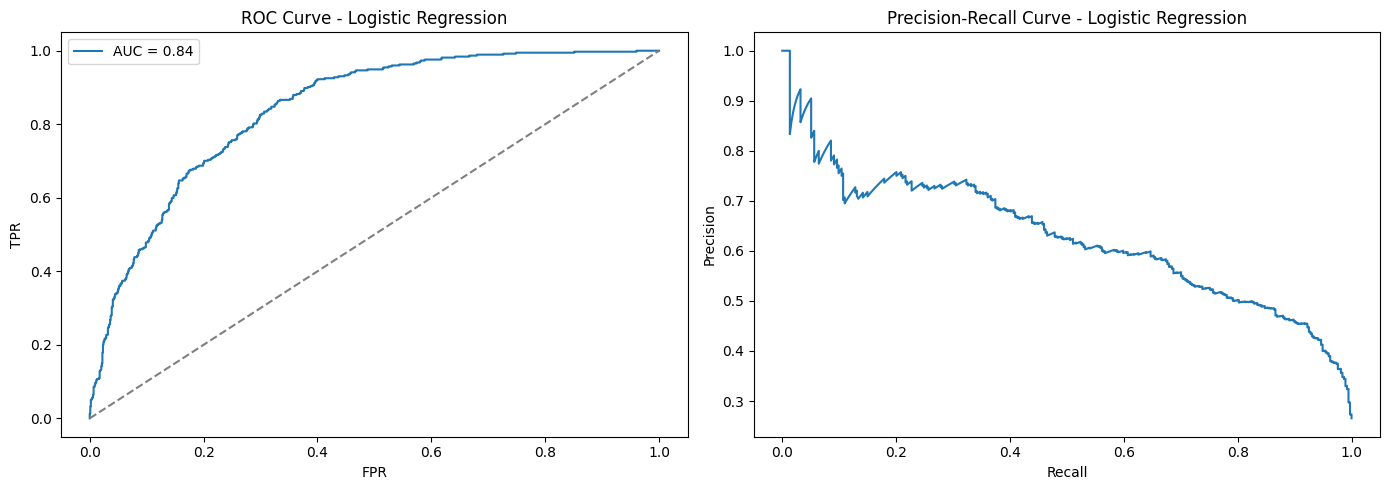

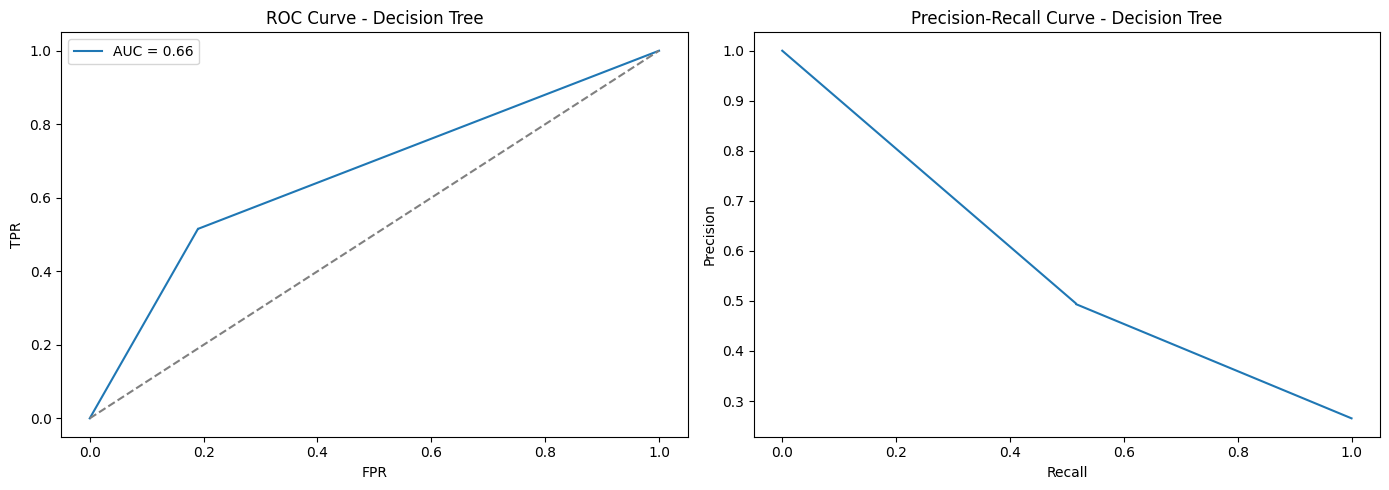

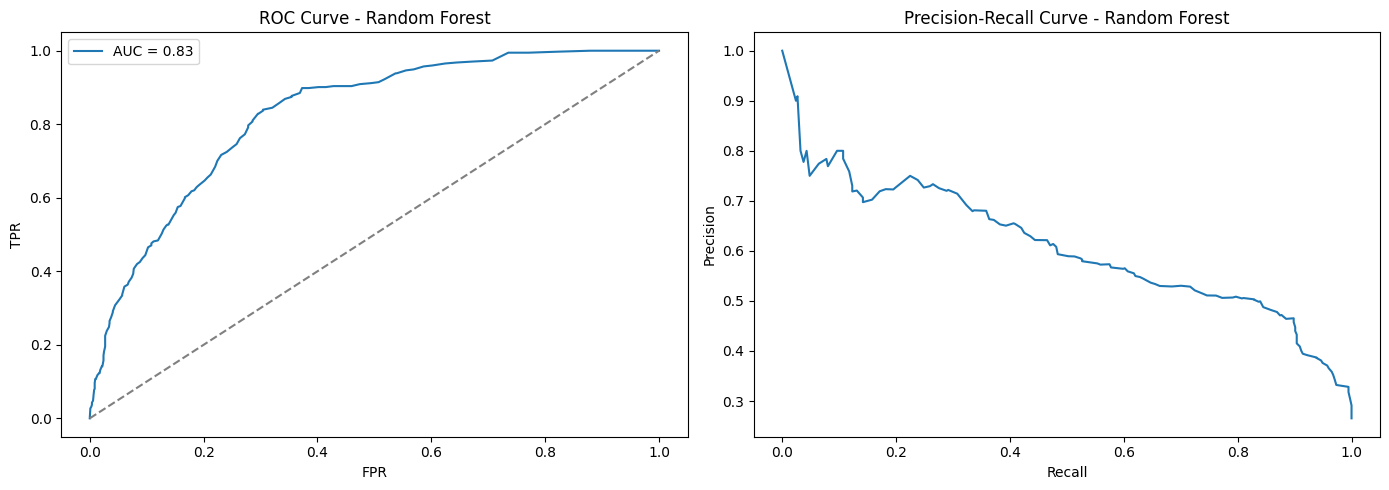

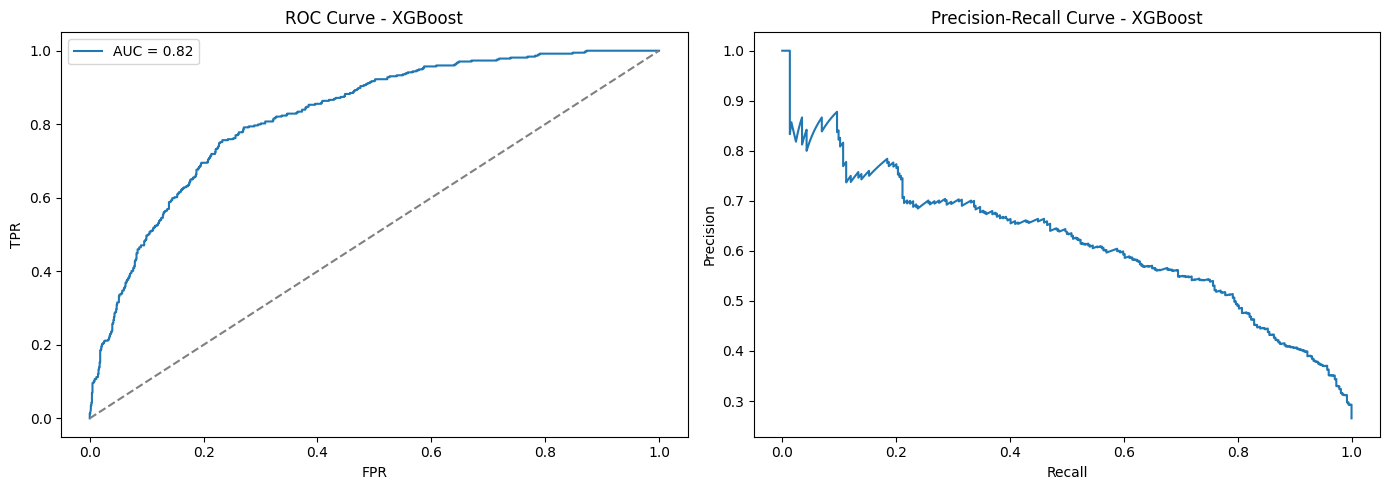

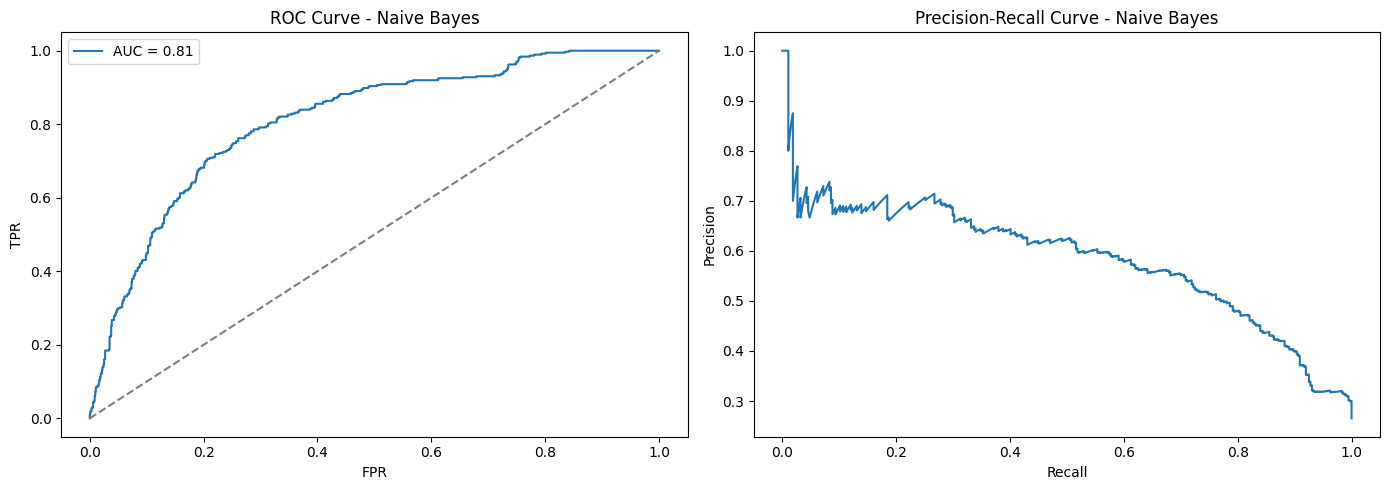

In [22]:
classifiers = {
    'Logistic Regression': LogisticRegression(n_jobs=-1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    # 'SVM': SVC(random_state=42),
    # 'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    # 'AdaBoost': AdaBoostClassifier(random_state=42),
    # 'Bagging': BaggingClassifier(random_state=42),
    # 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
    # 'MLP': MLPClassifier(random_state=42),
}

results_df = pd.DataFrame()

for model_name, model in classifiers.items():
    results_df = evaluate_model_full(
        model,
        X_train, y_train,
        X_test, y_test,
        model_name,
        results_df)

In [23]:
results_df.sort_values(by="Test Fβ", ascending=False)

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Train Fβ,Train MCC,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test Fβ,Test MCC,Test ROC AUC
0,Logistic Regression,0.739,0.714,0.786,0.748,0.770,0.480,0.814,0.762,0.495,0.829,0.620,0.730,0.465,0.840
4,Naive Bayes,0.710,0.666,0.826,0.737,0.788,0.431,0.783,0.722,0.426,0.864,0.571,0.717,0.393,0.809
3,XGBoost,0.851,0.853,0.844,0.849,0.846,0.702,0.936,0.721,0.601,0.580,0.590,0.584,0.446,0.824
2,Random Forest,0.862,0.846,0.880,0.863,0.873,0.724,0.931,0.709,0.567,0.578,0.572,0.575,0.416,0.826
1,Decision Tree,0.790,0.784,0.796,0.790,0.793,0.581,0.791,0.663,0.495,0.516,0.505,0.512,0.321,0.663


## Fine-tuning the model

In [24]:
def evaluate_and_plot(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'Train Accuracy': balanced_accuracy_score(y_train, y_train_pred),
        'Train Precision': precision_score(y_train, y_train_pred),
        'Train Recall': recall_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Train ROC AUC': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        'Test Accuracy': balanced_accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test ROC AUC': roc_auc_score(y_test, y_test_proba)
    }

    print(f"📊 Model: {name}")
    print(pd.Series(results))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, label=f"AUC = {results['Test ROC AUC']:.2f}")
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid()
    plt.show()

    return results

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Objective Functions for Optuna
def objective_logreg(trial):
    c = trial.suggest_loguniform('C', 1e-3, 10)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    model = LogisticRegression(C=c, penalty=penalty, solver=solver, class_weight='balanced', max_iter=1000)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()

# def objective_gb(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 400),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#     }
#     model = GradientBoostingClassifier(**params)
#     return cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()

# def objective_xgb(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 400),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#     }
#     model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', **params)
#     return cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()


In [27]:
storage = RDBStorage(url="sqlite:///optuna_study.db")

study_logreg = optuna.create_study(direction='maximize', study_name="logreg_churn", storage=storage, load_if_exists=True)
study_logreg.optimize(objective_logreg, n_trials=30)

# study_gb = optuna.create_study(direction='maximize', study_name="gb_churn", storage=storage, load_if_exists=True)
# study_gb.optimize(objective_gb, n_trials=30)

# study_xgb = optuna.create_study(direction='maximize', study_name="xgb_churn", storage=storage, load_if_exists=True)
# study_xgb.optimize(objective_xgb, n_trials=30)

pickle.dump(study_logreg.best_params, open('best_params_logreg.pkl', 'wb'))
# pickle.dump(study_gb.best_params, open('best_params_gb.pkl', 'wb'))
# pickle.dump(study_xgb.best_params, open('best_params_xgb.pkl', 'wb'))

logreg_model = LogisticRegression(**study_logreg.best_params, class_weight='balanced', max_iter=1000)
# gb_model = GradientBoostingClassifier(**study_gb.best_params)
# xgb_model = XGBClassifier(**study_xgb.best_params, use_label_encoder=False, eval_metric='logloss')

[I 2025-07-27 09:15:56,029] Using an existing study with name 'logreg_churn' instead of creating a new one.
[I 2025-07-27 09:15:57,313] Trial 0 finished with value: 0.7489956452567996 and parameters: {'C': 1.196199612919036, 'penalty': 'l1'}. Best is trial 0 with value: 0.7489956452567996.
[I 2025-07-27 09:15:59,267] Trial 1 finished with value: 0.7492879720739122 and parameters: {'C': 0.5318273249714199, 'penalty': 'l2'}. Best is trial 1 with value: 0.7492879720739122.
[I 2025-07-27 09:16:00,874] Trial 2 finished with value: 0.7494019795312469 and parameters: {'C': 0.4273759642706661, 'penalty': 'l2'}. Best is trial 2 with value: 0.7494019795312469.
[I 2025-07-27 09:16:02,051] Trial 3 finished with value: 0.7493473170410011 and parameters: {'C': 0.5886657633745357, 'penalty': 'l2'}. Best is trial 2 with value: 0.7494019795312469.
[I 2025-07-27 09:16:02,335] Trial 4 finished with value: 0.7265973516196456 and parameters: {'C': 0.011679285850971366, 'penalty': 'l1'}. Best is trial 2 wit

In [ ]:
# load best params
# xgb_params = optuna.load_study(study_name="xgb_churn", storage=storage).best_params
# logreg_params = optuna.load_study(study_name="logreg_churn", storage=storage).best_params
# gb_params = optuna.load_study(study_name="gb_churn", storage=storage).best_params

# logreg_model = LogisticRegression(**logreg_params)
# xgb_model = XGBClassifier(**xgb_params)
# gb_model = GradientBoostingClassifier(**gb_params)

📊 Model: Logistic Regression
Train Accuracy    0.738
Train Precision   0.711
Train Recall      0.790
Train F1          0.748
Train ROC AUC     0.817
Test Accuracy     0.763
Test Precision    0.491
Test Recall       0.842
Test F1           0.620
Test ROC AUC      0.839
dtype: float64


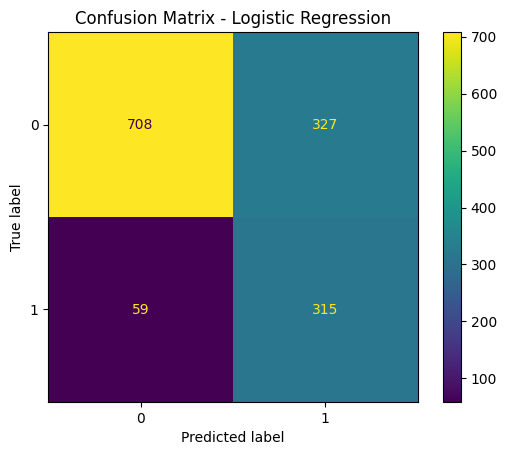

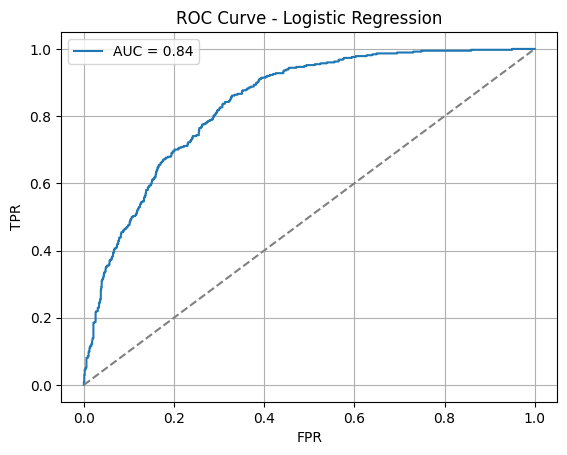


📌 Final Comparison:
                     Train Accuracy  Train Precision  Train Recall  Train F1  \
Logistic Regression           0.738            0.711         0.790     0.748   

                     Train ROC AUC  Test Accuracy  Test Precision  \
Logistic Regression          0.817          0.763           0.491   

                     Test Recall  Test F1  Test ROC AUC  
Logistic Regression        0.842    0.620         0.839  


In [28]:
results_all = {}
results_all['Logistic Regression'] = evaluate_and_plot(logreg_model, X_train, y_train, X_test, y_test, 'Logistic Regression')
# results_all['Gradient Boosting'] = evaluate_and_plot(gb_model, X_train, y_train, X_test, y_test, 'Gradient Boosting')
# results_all['XGBoost'] = evaluate_and_plot(xgb_model, X_train, y_train, X_test, y_test, 'XGBoost')

df_results = pd.DataFrame(results_all).T
print("\n📌 Final Comparison:")
print(df_results)

In [29]:
df_results

,Train Accuracy,Train Precision,Train Recall,Train F1,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC
Logistic Regression,0.738,0.711,0.790,0.748,0.817,0.763,0.491,0.842,0.620,0.839


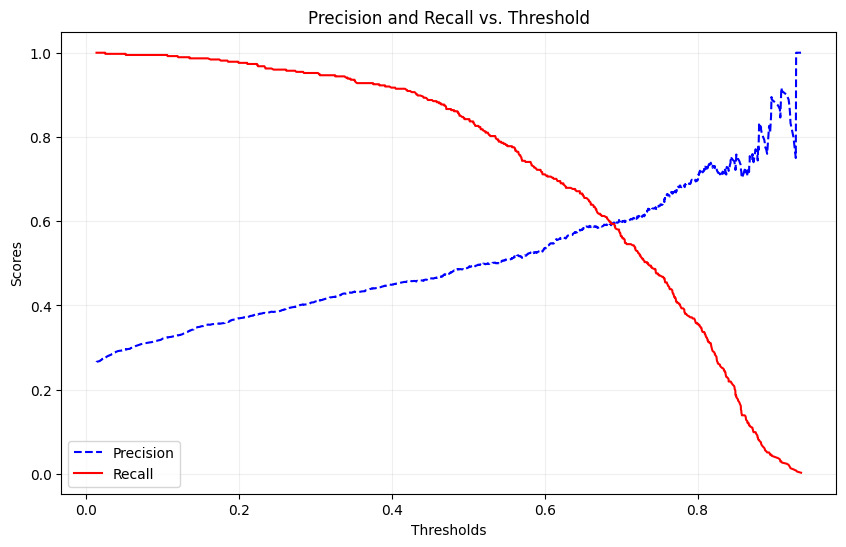

In [36]:
y_scores = logreg_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'r-', label='Recall')
plt.xlabel('Thresholds')
plt.ylabel('Scores')
plt.title("Precision and Recall vs. Threshold")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [37]:
best_thresh = 0
best_score = 0

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    fbeta = fbeta_score(y_test, y_pred_t, beta=1.5)
    if fbeta > best_score:
        best_score = fbeta
        best_thresh = t

print(f"Best Threshold: {best_thresh:.3f}, Best F1.5 Score: {best_score:.4f}")

Best Threshold: 0.417, Best F1.5 Score: 0.6984


In [39]:
y_pred_opt = (y_scores >= best_thresh).astype(int)

print("\n📊 Classification Report with Optimized Threshold:")
print(classification_report(y_test, y_pred_opt))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_opt))

print("\n🔍 ROC AUC:", roc_auc_score(y_test, y_scores))


📊 Classification Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.95      0.61      0.74      1035
           1       0.46      0.91      0.61       374

    accuracy                           0.69      1409
   macro avg       0.70      0.76      0.67      1409
weighted avg       0.82      0.69      0.71      1409


🧩 Confusion Matrix:
[[627 408]
 [ 32 342]]

🔍 ROC AUC: 0.839024516262368
